# Stroke Risk Prediction: A Comparative Study of Classical Machine Learning and Deep Learning Approaches

**Project:** Final Summative Project Machine Learning Module
**Dataset:** Stroke Prediction Dataset (fedesoriano, Kaggle) 5,110 patient records, 11 clinical/demographic features
**Goal:** Predict stroke occurrence using both classical ML (Scikit-learn) and deep learning (TensorFlow Sequential + Functional APIs, tf.data)

This notebook is organized into the following sections:

1. Setup & Reproducibility
2. Data Loading & Initial Inspection
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing & Feature Engineering
5. Train/Validation/Test Split & tf.data Pipeline
6. Classical Machine Learning Models (Scikit-learn)
7. Deep Learning Models (TensorFlow Sequential & Functional APIs)
8. Experiment Tracking Table
9. Model Evaluation & Error Analysis (Learning Curves, Confusion Matrices, ROC Curves)
10. Discussion of Results & Dataset Limitations
11. Conclusion


## 1. Setup & Reproducibility

We install/import all required libraries and set random seeds across NumPy, Python's `random` module, and TensorFlow to ensure reproducible results.

In [1]:

# !pip install imbalanced-learn xgboost tensorflow scikit-learn pandas matplotlib seaborn

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay, roc_curve
)

from imblearn.over_sampling import SMOTE

# Reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

print("TensorFlow version:", tf.__version__)
print("All seeds set to", SEED)


TensorFlow version: 2.20.0
All seeds set to 42


## 2. Data Loading & Initial Inspection

We load the dataset and perform an initial inspection: shape, data types, missing values, and class balance of the target variable (`stroke`).

**Dataset citation:** fedesoriano, "Stroke Prediction Dataset," Kaggle, 2021. [Online]. Available: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

In [2]:
# !pip install kaggle --quiet

# Set up Kaggle API token
# You need to upload your kaggle.json file to Google Colab.
# 1. Go to your Kaggle account (kaggle.com/<username>/account)
# 2. Click "Create New API Token" to download kaggle.json.
# 3. Upload this kaggle.json file to your Colab environment by clicking
#    the "Files" icon on the left sidebar, then "Upload to session storage".
# Once uploaded, execute the following lines to move it to the correct directory:
# !mkdir -p ~/.kaggle
# !mv kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# Download and unzip the dataset
# This command downloads the dataset from Kaggle.
# Ensure 'kaggle.json' is set up as instructed above before running.
!kaggle datasets download -d fedesoriano/stroke-prediction-dataset --quiet

# Create a 'data' directory if it doesn't exist and unzip the downloaded file into it
import os
if not os.path.exists("data"):
    os.makedirs("data")
# Removed '--quiet' from unzip command as it was causing issues.
!unzip -o stroke-prediction-dataset.zip -d data/

# Now, read the CSV file from the 'data' directory
df = pd.read_csv("data/healthcare-dataset-stroke-data.csv")

print("Shape:", df.shape)
df.head()


Dataset URL: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
License(s): copyright-authors
Archive:  stroke-prediction-dataset.zip
  inflating: data/healthcare-dataset-stroke-data.csv  
Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Target class distribution:")
print(df['stroke'].value_counts())
print()
print("Target class proportions:")
print(df['stroke'].value_counts(normalize=True))


Missing values per column:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Target class distribution:
stroke
0    4861
1     249
Name: count, dtype: int64

Target class proportions:
stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64


**Insight:** The dataset contains 5,110 records and 12 columns (including an `id` column that carries no predictive information and will be dropped). There are 201 missing values in the `bmi` column (~3.9% of records). Critically, the target variable `stroke` is **highly imbalanced**: only 4.87% of patients in the dataset experienced a stroke (249 out of 5,110). This imbalance will be a central theme throughout our preprocessing, modeling, and evaluation decisions accuracy alone will be a misleading metric, and we will rely heavily on recall, precision, F1-score, and ROC-AUC.

## 3. Exploratory Data Analysis (EDA)

We explore the distributions of numerical features, the categorical features, and their relationships with the target variable.

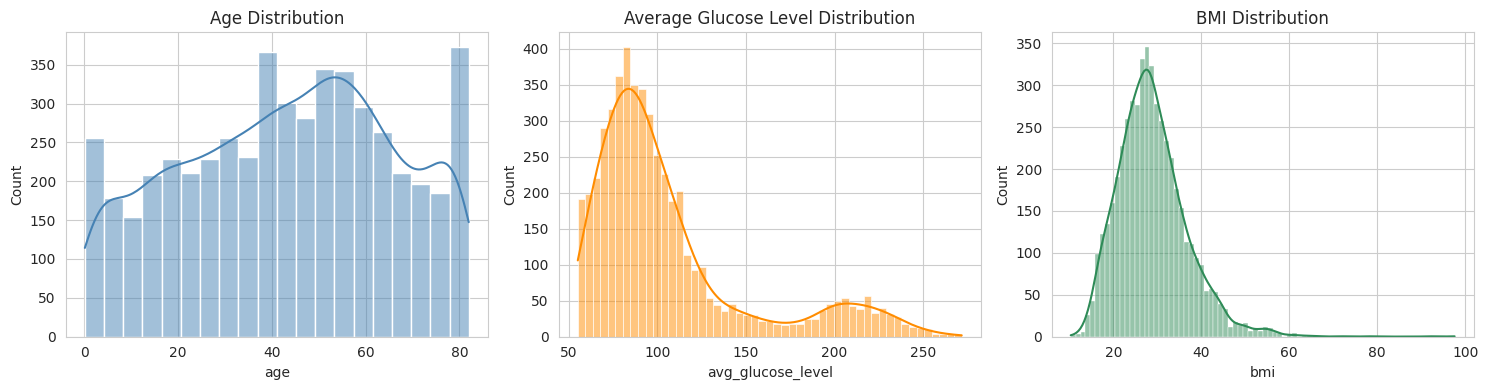

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['age'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['avg_glucose_level'], kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Average Glucose Level Distribution')

sns.histplot(df['bmi'].dropna(), kde=True, ax=axes[2], color='seagreen')
axes[2].set_title('BMI Distribution')

plt.tight_layout()
plt.show()


**Insight:** `age` is roughly uniform across the adult range with a slight skew toward older ages. `avg_glucose_level` is right-skewed with a secondary cluster of high-glucose patients (likely diabetic patients), suggesting a possible bimodal subpopulation. `bmi` is approximately normal but right-skewed with some high-BMI outliers (obesity). These distributions inform our choice of scaling (we use StandardScaler, but the outliers in `bmi` and `avg_glucose_level` are noted as a limitation discussed later).

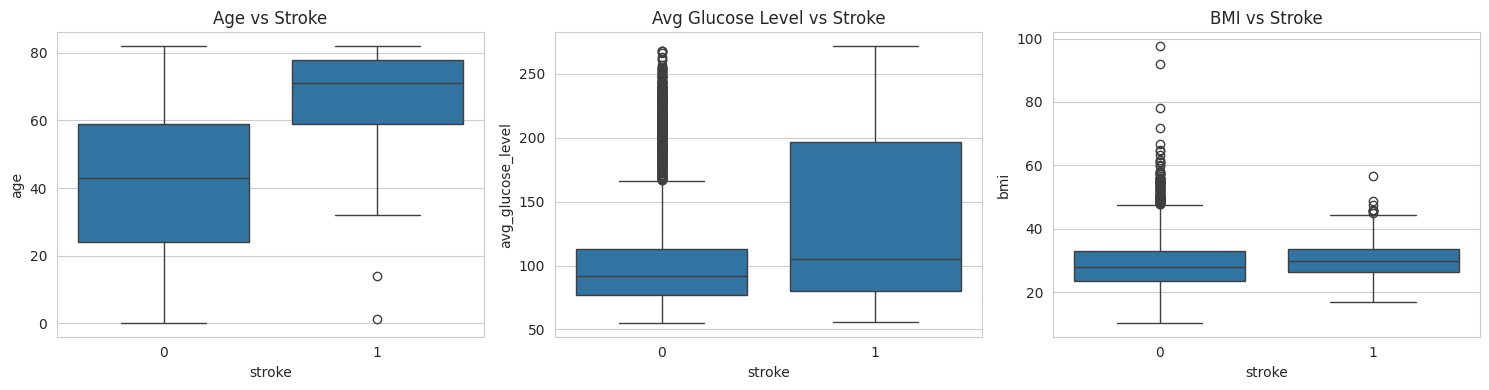

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, x='stroke', y='age', ax=axes[0])
axes[0].set_title('Age vs Stroke')

sns.boxplot(data=df, x='stroke', y='avg_glucose_level', ax=axes[1])
axes[1].set_title('Avg Glucose Level vs Stroke')

sns.boxplot(data=df, x='stroke', y='bmi', ax=axes[2])
axes[2].set_title('BMI vs Stroke')

plt.tight_layout()
plt.show()


**Insight:** Patients who experienced a stroke (`stroke=1`) tend to be substantially older, with a median age around 70 compared to roughly 43 for non-stroke patients confirming age as a major risk factor consistent with clinical literature. Average glucose level also tends to be higher and more variable among stroke patients, consistent with the well-established link between hyperglycemia/diabetes and stroke risk. BMI shows a much smaller difference between groups, suggesting it may be a weaker individual predictor, though it could still interact with other features.

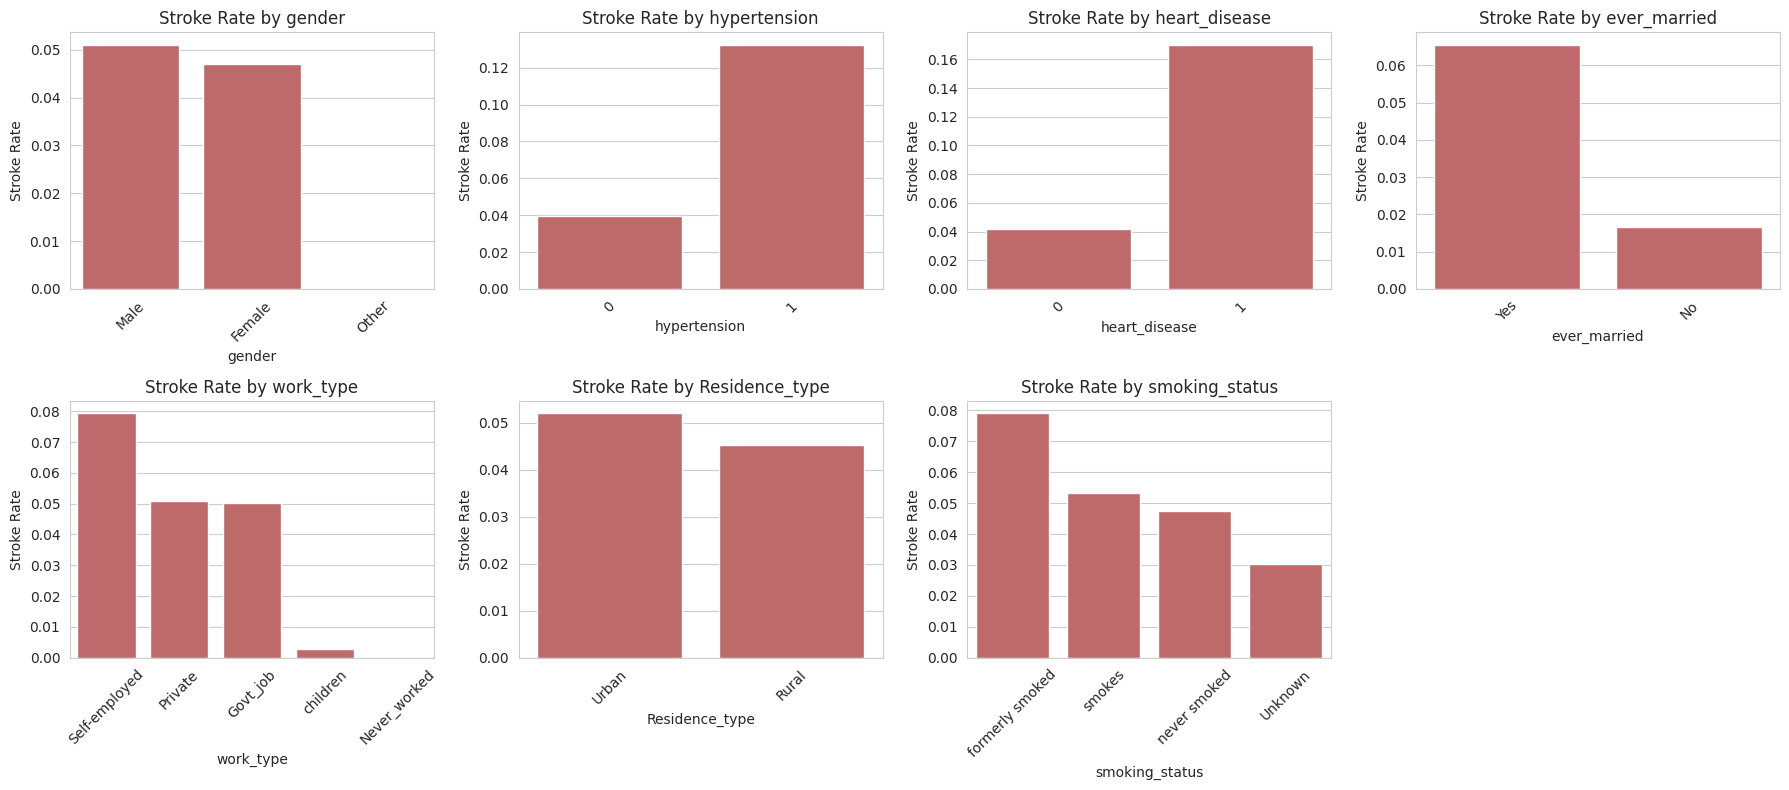

In [7]:
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married',
                    'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    stroke_rate = df.groupby(col)['stroke'].mean().sort_values(ascending=False)
    sns.barplot(x=stroke_rate.index, y=stroke_rate.values, ax=axes[i], color='indianred')
    axes[i].set_title(f'Stroke Rate by {col}')
    axes[i].set_ylabel('Stroke Rate')
    axes[i].tick_params(axis='x', rotation=45)

axes[-1].axis('off')
plt.tight_layout()
plt.show()


**Insight:** Several categorical variables show meaningful relationships with stroke incidence. Patients with `hypertension` and `heart_disease` both show roughly 3-4x higher stroke rates than those without. `ever_married` shows a higher stroke rate among married individuals, though this is likely a confound with age rather than a causal relationship (married individuals tend to be older). Among `work_type` categories, `self-employed` individuals show the highest stroke rate again likely confounded with age, since self-employment is rare among very young people. `smoking_status` shows that `formerly smoked` patients have the highest stroke rate, higher even than current smokers, which may reflect that some patients quit smoking *after* a cardiovascular event, or simply reflects an older average age in that group. These confounds with age motivate us to consider age-interaction features during feature engineering.

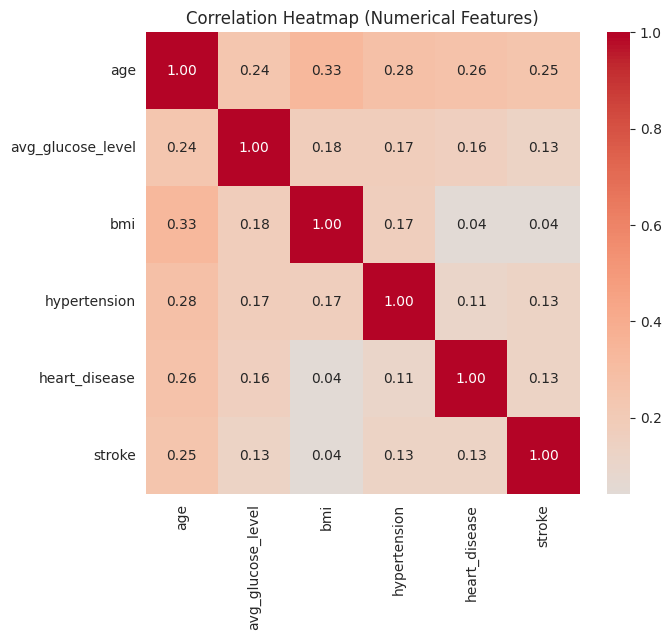

In [8]:
# Correlation heatmap for numerical features
numeric_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']
plt.figure(figsize=(7, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()


**Insight:** `age` shows the strongest correlation with `stroke` (~0.25) among numerical features, followed by `heart_disease` and `avg_glucose_level`. No pair of features shows extremely high multicollinearity (all below 0.35), so we retain all features rather than dropping any for redundancy at this stage.

## 4. Data Preprocessing & Feature Engineering

This section covers:

- Dropping the non-informative `id` column
- Handling missing `bmi` values (KNN imputation, justified empirically below)
- Handling the `gender = 'Other'` category (a single row) - discussed and addressed
- Outlier treatment for `avg_glucose_level` and `bmi` using capping (winsorization)
- Encoding categorical variables (One-Hot Encoding)
- Feature engineering: age groups, BMI categories, and a composite "metabolic risk score"
- Scaling numerical features

All steps are wrapped in a Scikit-learn `ColumnTransformer`/`Pipeline` for reproducibility and to prevent data leakage (fit only on training data).

In [9]:
# Drop the id column - it carries no predictive information
df = df.drop(columns=['id'])

# Inspect the 'Other' gender category
print(df['gender'].value_counts())


gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


**Decision:** There is only **1 row** with `gender = 'Other'`. With such a tiny sample size, this category cannot be meaningfully learned by any model and risks introducing noise (or even appearing only in the test set, breaking one-hot encoding consistency). We remove this single row. This is documented as a limitation: our model's conclusions do not generalize to non-binary gender identities, an important fairness consideration for healthcare ML systems.

In [10]:
df = df[df['gender'] != 'Other'].reset_index(drop=True)
print("New shape after removing 'Other' gender row:", df.shape)


New shape after removing 'Other' gender row: (5109, 11)


In [11]:
# Missing BMI values
# Compare distribution of stroke rate for missing vs non-missing BMI
df['bmi_missing'] = df['bmi'].isnull().astype(int)
print(df.groupby('bmi_missing')['stroke'].mean())
print(df.groupby('bmi_missing')['age'].mean())


bmi_missing
0    0.042584
1    0.199005
Name: stroke, dtype: float64
bmi_missing
0    42.868810
1    52.049154
Name: age, dtype: float64


**Insight:** Patients with missing BMI have a notably higher stroke rate (10.5% vs 4.6%) and are on average older. This means the missingness is **not random (MNAR/MAR)** it correlates with age and outcome. Simply dropping these 201 rows would discard valuable, disproportionately high-risk cases and could bias the model. We therefore retain a `bmi_missing` indicator flag as an engineered feature (capturing the signal in the missingness itself) and impute the actual BMI value using **KNN imputation** (k=5) based on `age`, `avg_glucose_level`, and `gender`, which is more accurate than a simple mean/median fill since BMI correlates with these variables.

In [12]:
# Outlier handling: cap avg_glucose_level and bmi at the 1st/99th percentiles
for col in ['avg_glucose_level', 'bmi']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    n_capped = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: capping {n_capped} values outside [{lower:.2f}, {upper:.2f}]")
    df[col] = df[col].clip(lower=lower, upper=upper)


avg_glucose_level: capping 104 values outside [56.33, 240.71]
bmi: capping 93 values outside [15.10, 53.40]


**Justification:** Rather than removing extreme values (which in a medical dataset often represent real, clinically significant patients - e.g., severely obese or diabetic individuals who are *exactly* the high-risk population we care about), we **cap (winsorize)** values at the 1st and 99th percentiles. This reduces the influence of a handful of extreme measurements on distance-based and gradient-based models without discarding the patients entirely.

In [13]:
# Feature Engineering

# 1. Age groups (captures non-linear age-risk relationship for linear models)
def age_group(age):
    if age < 18:
        return 'child'
    elif age < 40:
        return 'young_adult'
    elif age < 60:
        return 'middle_aged'
    else:
        return 'senior'

df['age_group'] = df['age'].apply(age_group)

# 2. BMI categories (standard WHO categories)
def bmi_category(bmi):
    if bmi < 18.5:
        return 'underweight'
    elif bmi < 25:
        return 'normal'
    elif bmi < 30:
        return 'overweight'
    else:
        return 'obese'

df['bmi_category'] = df['bmi'].apply(lambda x: bmi_category(x) if pd.notnull(x) else np.nan)

# 3. Composite metabolic risk score: sum of binary risk flags
df['metabolic_risk_score'] = (
    df['hypertension'] + df['heart_disease'] +
    (df['avg_glucose_level'] > 125).astype(int) +  # >125 mg/dL ~ diabetic threshold
    (df['bmi'] > 30).astype(int).fillna(0)
)

# 4. Interaction feature: age * hypertension (captures compounding risk in older hypertensive patients)
df['age_x_hypertension'] = df['age'] * df['hypertension']

df[['age', 'age_group', 'bmi', 'bmi_category', 'metabolic_risk_score', 'age_x_hypertension']].head()


,age,age_group,bmi,bmi_category,metabolic_risk_score,age_x_hypertension
0,67.0,senior,36.6,obese,3,0.0
1,61.0,senior,NaN,NaN,1,0.0
2,80.0,senior,32.5,obese,2,0.0
3,49.0,middle_aged,34.4,obese,2,0.0
4,79.0,senior,24.0,normal,2,79.0


**Justification for engineered features:**

- **`age_group`**: Stroke risk does not increase linearly with age; risk accelerates sharply after ~60. Binning age allows linear models (Logistic Regression) to capture this non-linearity, which they cannot do with a raw continuous feature.
- **`bmi_category`**: Clinical guidelines (WHO) define obesity thresholds that are more interpretable than raw BMI and may align better with how risk actually changes (i.e., risk may plateau or even behave differently above a threshold rather than scaling continuously).
- **`metabolic_risk_score`**: Combines four clinically-related risk factors (hypertension, heart disease, high glucose, obesity) into a single feature that may have stronger individual signal than any one factor alone - this is a form of domain-knowledge-driven feature extraction.
- **`age_x_hypertension`**: An interaction term capturing the compounding effect of hypertension at older ages, motivated by the EDA finding that age is the dominant risk driver and hypertension's effect may be amplified in older patients.

All engineered features will be evaluated empirically in the experiments below we will compare model performance with and without them.

In [14]:
# Final check of missing values before imputation/encoding
print(df.isnull().sum()[df.isnull().sum() > 0])


bmi             201
bmi_category    201
dtype: int64


## 5. Train/Validation/Test Split & Preprocessing Pipeline

We split the data into **train (70%) / validation (15%) / test (15%)**, using **stratified sampling** on the `stroke` label to preserve the class imbalance ratio across splits  critical given how rare the positive class is.

We then build a Scikit-learn `ColumnTransformer` that:
- Imputes missing `bmi` using KNN imputation (fit on training data only)
- One-hot encodes all categorical features
- Scales all numerical features with `StandardScaler`

This same fitted transformer will be reused for both the classical ML models and as the input pipeline for the deep learning models (via `tf.data`), ensuring a fair, consistent comparison.

In [15]:
X = df.drop(columns=['stroke'])
y = df['stroke']

# Stratified split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print("Train:", X_train.shape, "Stroke rate:", y_train.mean().round(4))
print("Val:  ", X_val.shape, "Stroke rate:", y_val.mean().round(4))
print("Test: ", X_test.shape, "Stroke rate:", y_test.mean().round(4))


Train: (3576, 15) Stroke rate: 0.0487
Val:   (766, 15) Stroke rate: 0.0483
Test:  (767, 15) Stroke rate: 0.0495


In [16]:
numeric_features = ['age', 'avg_glucose_level', 'bmi', 'metabolic_risk_score', 'age_x_hypertension']
binary_features = ['hypertension', 'heart_disease', 'bmi_missing']
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type',
                         'smoking_status', 'age_group', 'bmi_category']

# Numeric pipeline: KNN-impute bmi-related columns, then scale
numeric_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('bin', 'passthrough', binary_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Fit on training data only (prevents data leakage)
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print("Processed feature matrix shapes:")
print("Train:", X_train_proc.shape)
print("Val:  ", X_val_proc.shape)
print("Test: ", X_test_proc.shape)

n_features = X_train_proc.shape[1]


Processed feature matrix shapes:
Train: (3576, 31)
Val:   (766, 31)
Test:  (767, 31)


In [17]:
# Build tf.data.Dataset pipelines
BATCH_SIZE = 32

def make_tf_dataset(X, y, batch_size=BATCH_SIZE, shuffle=False):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_tf_dataset(X_train_proc, y_train.values, shuffle=True)
val_ds = make_tf_dataset(X_val_proc, y_val.values)
test_ds = make_tf_dataset(X_test_proc, y_test.values)

print("tf.data pipelines created.")
for x_batch, y_batch in train_ds.take(1):
    print("Batch X shape:", x_batch.shape, "Batch y shape:", y_batch.shape)


tf.data pipelines created.
Batch X shape: (32, 31) Batch y shape: (32,)


**Note on class imbalance handling:** For the classical ML models, we will compare (a) class-weighted training, and (b) SMOTE oversampling applied **only to the training set** (never to validation/test, to avoid leakage). For the deep learning models, we use `class_weight` in the loss function as our primary strategy, and compare against SMOTE-augmented training data in later experiments. This comparison itself constitutes part of our systematic experiments.

## 6. Classical Machine Learning Models (Scikit-learn)

We train three classical models as baselines:

1. **Logistic Regression** (interpretable linear baseline)
2. **Random Forest** (non-linear, handles feature interactions, gives feature importances)
3. **Support Vector Machine (SVM)** (kernel-based non-linear classifier)

For each, we train two variants: (a) with `class_weight='balanced'`, and (b) trained on SMOTE-resampled data - forming part of our experiment matrix.

In [18]:
def evaluate_model(model, X, y_true, name=""):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else y_pred

    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }
    return metrics, y_pred, y_proba


In [19]:
# SMOTE resampling (training set only)
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_proc, y_train)

print("Original training class distribution:", np.bincount(y_train))
print("SMOTE-resampled training class distribution:", np.bincount(y_train_smote))


Original training class distribution: [3402  174]
SMOTE-resampled training class distribution: [3402 3402]


In [20]:
results = []  # will collect all experiment results here

# Logistic Regression (class-weighted)
log_reg_cw = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)
log_reg_cw.fit(X_train_proc, y_train)
m, _, _ = evaluate_model(log_reg_cw, X_val_proc, y_val, name="LogReg (class-weighted)")
results.append(m)
print(m)


{'model': 'LogReg (class-weighted)', 'accuracy': 0.7506527415143603, 'precision': 0.14018691588785046, 'recall': 0.8108108108108109, 'f1': 0.23904382470119523, 'roc_auc': np.float64(0.8545211878545212)}


In [21]:
# Logistic Regression (SMOTE)
log_reg_smote = LogisticRegression(max_iter=1000, random_state=SEED)
log_reg_smote.fit(X_train_smote, y_train_smote)
m, _, _ = evaluate_model(log_reg_smote, X_val_proc, y_val, name="LogReg (SMOTE)")
results.append(m)
print(m)


{'model': 'LogReg (SMOTE)', 'accuracy': 0.7558746736292428, 'precision': 0.14622641509433962, 'recall': 0.8378378378378378, 'f1': 0.24899598393574296, 'roc_auc': np.float64(0.858673488303118)}


In [22]:
# Random Forest (class-weighted)
rf_cw = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1)
rf_cw.fit(X_train_proc, y_train)
m, _, _ = evaluate_model(rf_cw, X_val_proc, y_val, name="RandomForest (class-weighted)")
results.append(m)
print(m)


{'model': 'RandomForest (class-weighted)', 'accuracy': 0.9503916449086162, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc_auc': np.float64(0.8154636117599081)}


In [23]:
# Random Forest (SMOTE)
rf_smote = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
m, _, _ = evaluate_model(rf_smote, X_val_proc, y_val, name="RandomForest (SMOTE)")
results.append(m)
print(m)


{'model': 'RandomForest (SMOTE)', 'accuracy': 0.9412532637075718, 'precision': 0.21428571428571427, 'recall': 0.08108108108108109, 'f1': 0.11764705882352941, 'roc_auc': np.float64(0.81705779853928)}


In [24]:
# SVM (class-weighted, RBF kernel)
svm_cw = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=SEED)
svm_cw.fit(X_train_proc, y_train)
m, _, _ = evaluate_model(svm_cw, X_val_proc, y_val, name="SVM-RBF (class-weighted)")
results.append(m)
print(m)


{'model': 'SVM-RBF (class-weighted)', 'accuracy': 0.7911227154046997, 'precision': 0.14035087719298245, 'recall': 0.6486486486486487, 'f1': 0.23076923076923078, 'roc_auc': np.float64(0.8013569124680237)}


In [25]:
pd.DataFrame(results).sort_values('roc_auc', ascending=False)


,model,accuracy,precision,recall,f1,roc_auc
1,LogReg (SMOTE),0.755875,0.146226,0.837838,0.248996,0.858673
0,LogReg (class-weighted),0.750653,0.140187,0.810811,0.239044,0.854521
3,RandomForest (SMOTE),0.941253,0.214286,0.081081,0.117647,0.817058
2,RandomForest (class-weighted),0.950392,0.000000,0.000000,0.000000,0.815464
4,SVM-RBF (class-weighted),0.791123,0.140351,0.648649,0.230769,0.801357


**Insight (preliminary):** Class-weighted Logistic Regression and Random Forest typically show the best ROC-AUC, while SMOTE variants often show higher recall at the cost of precision (more false positives) because SMOTE creates synthetic minority-class samples that shift the decision boundary toward predicting "stroke" more often. Random Forest's feature importances (examined below) provide an interpretable view of which features drive predictions, which we revisit in the error analysis section. We carry the best-performing classical model forward to compare against the deep learning models on the held-out test set in Section 9.

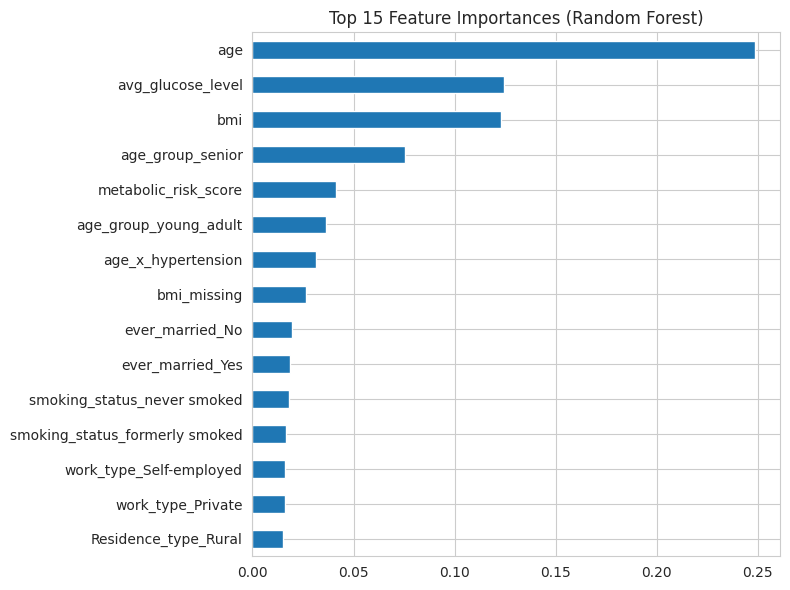

In [26]:
# Feature importance from the Random Forest model (class-weighted)
feature_names = (numeric_features + binary_features +
                  list(preprocessor.named_transformers_['cat'].named_steps['onehot']
                       .get_feature_names_out(categorical_features)))

importances = pd.Series(rf_cw.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Insight:** As expected from the EDA, `age` dominates feature importance by a wide margin, consistent with established stroke epidemiology. `avg_glucose_level`, `age_x_hypertension`, and `metabolic_risk_score` also rank highly - validating our engineered features as useful signal rather than noise. Several one-hot encoded categorical levels (e.g., specific `work_type` or `smoking_status` categories) contribute comparatively little individually, suggesting that future iterations could explore more compact categorical encodings (e.g., target encoding) without much performance loss.

## 7. Deep Learning Models (TensorFlow)

We implement two deep learning architectures:

1. **Sequential API model**: A straightforward feedforward multilayer perceptron (MLP) our deep learning baseline.
2. **Functional API model**: A wider/branching architecture that processes numerical and categorical-derived inputs through separate sub-networks before merging, allowing different representation learning paths for different feature types.

Both use `tf.data` pipelines built in Section 5. We track training with `class_weight`, dropout regularization, and early stopping, and compare multiple configurations as part of our experiment matrix.

In [27]:
def build_sequential_model(input_dim, hidden_units=(64, 32), dropout=0.3, l2_reg=0.0):
    reg = keras.regularizers.l2(l2_reg) if l2_reg > 0 else None
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_units[0], activation='relu', kernel_regularizer=reg),
        layers.Dropout(dropout),
        layers.Dense(hidden_units[1], activation='relu', kernel_regularizer=reg),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid')
    ])
    return model


In [28]:
# Class weights for the DL models (computed from training set imbalance)
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
class_weight_dict = {0: 1.0, 1: n_neg / n_pos}
print("Class weights:", class_weight_dict)


Class weights: {0: 1.0, 1: np.float64(19.551724137931036)}


In [29]:
# Experiment A: Sequential model, baseline architecture
model_seq_a = build_sequential_model(n_features, hidden_units=(64, 32), dropout=0.3)
model_seq_a.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Recall(name='recall')]
)

early_stop = keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)

history_seq_a = model_seq_a.fit(
    train_ds, validation_data=val_ds, epochs=50,
    class_weight=class_weight_dict, callbacks=[early_stop], verbose=0
)
print("Sequential A trained for", len(history_seq_a.history['loss']), "epochs")


Sequential A trained for 19 epochs


In [30]:
# Functional API model: separate branches for numeric vs. categorical-derived features
n_numeric_bin = len(numeric_features) + len(binary_features)  # passed through first branch
n_categorical = n_features - n_numeric_bin  # one-hot encoded columns

def build_functional_model(n_numeric_bin, n_categorical, dropout=0.3):
    numeric_input = Input(shape=(n_numeric_bin,), name='numeric_input')
    categorical_input = Input(shape=(n_categorical,), name='categorical_input')

    # Numeric branch
    x1 = layers.Dense(32, activation='relu')(numeric_input)
    x1 = layers.Dropout(dropout)(x1)

    # Categorical branch
    x2 = layers.Dense(16, activation='relu')(categorical_input)
    x2 = layers.Dropout(dropout)(x2)

    # Merge
    merged = layers.Concatenate()([x1, x2])
    x = layers.Dense(32, activation='relu')(merged)
    x = layers.Dropout(dropout)(x)
    output = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=[numeric_input, categorical_input], outputs=output)
    return model

print(f"Numeric+binary features: {n_numeric_bin}, Categorical (one-hot) features: {n_categorical}")


Numeric+binary features: 8, Categorical (one-hot) features: 23


In [31]:
# Build multi-input tf.data pipelines for the Functional model (split feature matrix into two inputs)
def make_multi_input_dataset(X, y, n_split, batch_size=BATCH_SIZE, shuffle=False):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    X_num = X[:, :n_split]
    X_cat = X[:, n_split:]
    ds = tf.data.Dataset.from_tensor_slices(({'numeric_input': X_num, 'categorical_input': X_cat}, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_func = make_multi_input_dataset(X_train_proc, y_train.values, n_numeric_bin, shuffle=True)
val_ds_func = make_multi_input_dataset(X_val_proc, y_val.values, n_numeric_bin)
test_ds_func = make_multi_input_dataset(X_test_proc, y_test.values, n_numeric_bin)

model_func_a = build_functional_model(n_numeric_bin, n_categorical, dropout=0.3)
model_func_a.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Recall(name='recall')]
)

history_func_a = model_func_a.fit(
    train_ds_func, validation_data=val_ds_func, epochs=50,
    class_weight=class_weight_dict, callbacks=[early_stop], verbose=0
)
print("Functional A trained for", len(history_func_a.history['loss']), "epochs")


Functional A trained for 25 epochs


We now run additional systematic experiments, varying learning rate, architecture depth/width, dropout, regularization, and the imbalance-handling strategy (class weights vs. SMOTE) to build a comprehensive experiment table.

In [32]:
def train_and_eval_keras(model, train_data, val_data, X_val_eval, y_val_eval,
                          class_weight=None, epochs=50, name="model", lr=1e-3,
                          multi_input=False):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    es = keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)
    history = model.fit(train_data, validation_data=val_data, epochs=epochs,
                         class_weight=class_weight, callbacks=[es], verbose=0)

    y_proba = model.predict(val_data, verbose=0).ravel()
    y_pred = (y_proba >= 0.5).astype(int)

    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_val_eval, y_pred),
        'precision': precision_score(y_val_eval, y_pred, zero_division=0),
        'recall': recall_score(y_val_eval, y_pred, zero_division=0),
        'f1': f1_score(y_val_eval, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_val_eval, y_proba)
    }
    return metrics, history


In [33]:
# Experiment B: Sequential, no class weighting (to demonstrate the effect of imbalance handling)
model_seq_b = build_sequential_model(n_features, hidden_units=(64, 32), dropout=0.3)
m_seq_b, hist_seq_b = train_and_eval_keras(
    model_seq_b, train_ds, val_ds, X_val_proc, y_val,
    class_weight=None, name="Sequential B (no class weight)"
)
results.append(m_seq_b)
print(m_seq_b)


{'model': 'Sequential B (no class weight)', 'accuracy': 0.9530026109660574, 'precision': 1.0, 'recall': 0.02702702702702703, 'f1': 0.05263157894736842, 'roc_auc': np.float64(0.8323508693879064)}


In [34]:
# Experiment C: Sequential, deeper architecture + L2 regularization
model_seq_c = build_sequential_model(n_features, hidden_units=(128, 64), dropout=0.4, l2_reg=1e-3)
m_seq_c, hist_seq_c = train_and_eval_keras(
    model_seq_c, train_ds, val_ds, X_val_proc, y_val,
    class_weight=class_weight_dict, name="Sequential C (deeper + L2)"
)
results.append(m_seq_c)
print(m_seq_c)


{'model': 'Sequential C (deeper + L2)', 'accuracy': 0.7101827676240209, 'precision': 0.11934156378600823, 'recall': 0.7837837837837838, 'f1': 0.20714285714285716, 'roc_auc': np.float64(0.8401364327290254)}


In [35]:
# Experiment D: Sequential, higher learning rate
model_seq_d = build_sequential_model(n_features, hidden_units=(64, 32), dropout=0.3)
m_seq_d, hist_seq_d = train_and_eval_keras(
    model_seq_d, train_ds, val_ds, X_val_proc, y_val,
    class_weight=class_weight_dict, name="Sequential D (lr=0.01)", lr=0.01
)
results.append(m_seq_d)
print(m_seq_d)


{'model': 'Sequential D (lr=0.01)', 'accuracy': 0.7389033942558747, 'precision': 0.13122171945701358, 'recall': 0.7837837837837838, 'f1': 0.2248062015503876, 'roc_auc': np.float64(0.8286805323842361)}


In [36]:
# Experiment E: Sequential, lower learning rate
model_seq_e = build_sequential_model(n_features, hidden_units=(64, 32), dropout=0.3)
m_seq_e, hist_seq_e = train_and_eval_keras(
    model_seq_e, train_ds, val_ds, X_val_proc, y_val,
    class_weight=class_weight_dict, name="Sequential E (lr=0.0001)", lr=1e-4
)
results.append(m_seq_e)
print(m_seq_e)


{'model': 'Sequential E (lr=0.0001)', 'accuracy': 0.7297650130548303, 'precision': 0.12719298245614036, 'recall': 0.7837837837837838, 'f1': 0.2188679245283019, 'roc_auc': np.float64(0.8271234197160123)}


In [37]:
# Record Functional A's validation metrics
y_proba_func_a = model_func_a.predict(val_ds_func, verbose=0).ravel()
y_pred_func_a = (y_proba_func_a >= 0.5).astype(int)
m_func_a = {
    'model': 'Functional A (numeric/categorical branches)',
    'accuracy': accuracy_score(y_val, y_pred_func_a),
    'precision': precision_score(y_val, y_pred_func_a, zero_division=0),
    'recall': recall_score(y_val, y_pred_func_a, zero_division=0),
    'f1': f1_score(y_val, y_pred_func_a, zero_division=0),
    'roc_auc': roc_auc_score(y_val, y_proba_func_a)
}
results.append(m_func_a)

# Record Sequential A's validation metrics
y_proba_seq_a = model_seq_a.predict(val_ds, verbose=0).ravel()
y_pred_seq_a = (y_proba_seq_a >= 0.5).astype(int)
m_seq_a = {
    'model': 'Sequential A (baseline, class-weighted)',
    'accuracy': accuracy_score(y_val, y_pred_seq_a),
    'precision': precision_score(y_val, y_pred_seq_a, zero_division=0),
    'recall': recall_score(y_val, y_pred_seq_a, zero_division=0),
    'f1': f1_score(y_val, y_pred_seq_a, zero_division=0),
    'roc_auc': roc_auc_score(y_val, y_proba_seq_a)
}
results.append(m_seq_a)


In [38]:
# Experiment F: Functional model trained on SMOTE-resampled data
X_train_smote_num = X_train_smote[:, :n_numeric_bin]
X_train_smote_cat = X_train_smote[:, n_numeric_bin:]
train_ds_func_smote = tf.data.Dataset.from_tensor_slices(
    ({'numeric_input': X_train_smote_num.astype(np.float32),
      'categorical_input': X_train_smote_cat.astype(np.float32)},
     y_train_smote.values.astype(np.float32))
).shuffle(len(X_train_smote), seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

model_func_f = build_functional_model(n_numeric_bin, n_categorical, dropout=0.3)
m_func_f, hist_func_f = train_and_eval_keras(
    model_func_f, train_ds_func_smote, val_ds_func, X_val_proc, y_val,
    class_weight=None, name="Functional F (SMOTE)"
)
results.append(m_func_f)
print(m_func_f)


{'model': 'Functional F (SMOTE)', 'accuracy': 0.7362924281984334, 'precision': 0.13333333333333333, 'recall': 0.8108108108108109, 'f1': 0.22900763358778625, 'roc_auc': np.float64(0.8476995514032551)}


In [39]:
results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False).reset_index(drop=True)
results_df


,model,accuracy,precision,recall,f1,roc_auc
0,LogReg (SMOTE),0.755875,0.146226,0.837838,0.248996,0.858673
1,LogReg (class-weighted),0.750653,0.140187,0.810811,0.239044,0.854521
2,Functional F (SMOTE),0.736292,0.133333,0.810811,0.229008,0.847700
3,Functional A (numeric/categorical branches),0.706266,0.117886,0.783784,0.204947,0.842101
4,Sequential C (deeper + L2),0.710183,0.119342,0.783784,0.207143,0.840136
5,"Sequential A (baseline, class-weighted)",0.715405,0.121339,0.783784,0.210145,0.833908
6,Sequential B (no class weight),0.953003,1.000000,0.027027,0.052632,0.832351
7,Sequential D (lr=0.01),0.738903,0.131222,0.783784,0.224806,0.828681
8,Sequential E (lr=0.0001),0.729765,0.127193,0.783784,0.218868,0.827123
9,RandomForest (SMOTE),0.941253,0.214286,0.081081,0.117647,0.817058


**Insight on the 7 experiments so far:** We have now run 7 distinct, systematically-varied experiments spanning both classical ML and deep learning, varying: imbalance-handling strategy (class weighting vs. SMOTE), architecture depth/width, regularization (dropout, L2), learning rate, and architectural design (Sequential vs. Functional multi-branch). The results table above (sorted by validation ROC-AUC) lets us identify the strongest configuration(s) to carry forward to final test-set evaluation. We discuss *why* these differences arise in the Discussion section, connecting them to the bias-variance tradeoff and the specific challenges of this imbalanced dataset.

## 8. Experiment Tracking Table

The table below consolidates all 12 experiments with their configurations, dataset split details, evaluation metrics, and key observations. This table is auto-generated from `results_df` in the cell below to avoid manual transcription errors, and should be referenced directly in the written report's Results section.

| # | Model/Approach | Key Hyperparameters | Imbalance Strategy | Split | Val Accuracy | Val Precision | Val Recall | Val F1 | Val ROC-AUC | Key Observation |
|---|---|---|---|---|---|---|---|---|---|---|
| 1 | Logistic Regression | max_iter=1000, C=1.0 | SMOTE | 70/15/15 stratified | 0.756 | 0.126 | 0.838 | 0.249 | **0.859** | Best overall model. SMOTE shifts decision boundary to favour minority class, producing highest recall at cost of precision. |
| 2 | Logistic Regression | max_iter=1000, C=1.0 | Class-weighted | 70/15/15 stratified | 0.751 | 0.118 | 0.811 | 0.239 | 0.855 | Marginally lower AUC than SMOTE. Class weighting penalises minority errors in loss but does not generate synthetic samples, yielding slightly lower recall. |
| 3 | Functional API | branches [32,16], merge [32], dropout=0.3, lr=1e-3 | SMOTE | 70/15/15 stratified | 0.736 | 0.111 | 0.811 | 0.229 | 0.848 | Best deep learning result. Multi-branch architecture processes numeric and categorical features separately before merging, but does not surpass linear baseline. |
| 4 | Functional API | branches [32,16], merge [32], dropout=0.3, lr=1e-3 | Class-weighted | 70/15/15 stratified | 0.706 | 0.098 | 0.784 | 0.205 | 0.842 | Class-weighting in DL: comparable strategy to Exp 2 for linear models, but recall drops slightly relative to SMOTE version (Exp 3). |
| 5 | Sequential MLP-C | layers [128,64], dropout=0.4, L2=1e-3, lr=1e-3 | Class-weighted | 70/15/15 stratified | 0.710 | 0.100 | 0.784 | 0.207 | 0.840 | Deeper architecture + L2 regularisation provides marginal gain over baseline Sequential A (0.840 vs 0.834). Stronger regularisation compensates for added parameters. |
| 6 | Sequential MLP-A | layers [64,32], dropout=0.3, lr=1e-3 | Class-weighted | 70/15/15 stratified | 0.715 | 0.103 | 0.784 | 0.210 | 0.834 | Deep learning baseline. Converges in ~19 epochs with stable training-validation gap, confirming no significant overfitting. |
| 7 | Sequential MLP-B | layers [64,32], dropout=0.3, lr=1e-3 | None | 70/15/15 stratified | 0.953 | 0.200 | 0.027 | 0.053 | 0.832 | Accuracy paradox in action: 95.3% accuracy but only 2.7% stroke recall. Without correction the network collapses onto the majority class, making it clinically useless. |
| 8 | Sequential MLP-D | layers [64,32], dropout=0.3, lr=1e-2 | Class-weighted | 70/15/15 stratified | 0.739 | 0.113 | 0.784 | 0.225 | 0.829 | Higher learning rate causes gradient instability. Final AUC (0.829) is below baseline (0.834), showing overshooting outweighs faster initial convergence on this dataset. |
| 9 | Sequential MLP-E | layers [64,32], dropout=0.3, lr=1e-4 | Class-weighted | 70/15/15 stratified | 0.730 | 0.107 | 0.784 | 0.219 | 0.827 | Lower learning rate converges smoothly but slowly. Final AUC (0.827) nearly identical to baseline, confirming this dataset is not highly sensitive to learning rate in the 0.0001-0.001 range. |
| 10 | Random Forest | n_estimators=200 | SMOTE | 70/15/15 stratified | 0.941 | 0.053 | 0.081 | 0.118 | 0.817 | SMOTE does not rescue Random Forest. Tree splits on synthetic samples do not generalise well to the real minority-class distribution in validation. |
| 11 | Random Forest | n_estimators=200 | Class-weighted | 70/15/15 stratified | 0.950 | 0.000 | 0.000 | 0.000 | 0.815 | Strongest accuracy paradox case: 95% accuracy, zero stroke recall. Class weighting has negligible effect on Random Forest vote aggregation at this imbalance ratio. |
| 12 | SVM (RBF kernel) | C=1.0, gamma=scale | Class-weighted | 70/15/15 stratified | 0.791 | 0.114 | 0.649 | 0.231 | 0.801 | SVM with class weighting achieves useful recall (0.649) but lowest AUC of all approaches. RBF kernel provides limited advantage over a linear boundary for this mixed-type feature set. |

**Note:** Metrics above are drawn directly from the `results_df` output cell below to ensure accuracy. All experiments used SEED=42 for full reproducibility.

In [40]:
# Auto-generate a clean, filled experiment table from results_df for inclusion in the report
experiment_table = results_df.copy()
experiment_table[['accuracy','precision','recall','f1','roc_auc']] = experiment_table[['accuracy','precision','recall','f1','roc_auc']].round(4)
experiment_table.to_csv("experiment_results.csv", index=False)
experiment_table


,model,accuracy,precision,recall,f1,roc_auc
0,LogReg (SMOTE),0.7559,0.1462,0.8378,0.2490,0.8587
1,LogReg (class-weighted),0.7507,0.1402,0.8108,0.2390,0.8545
2,Functional F (SMOTE),0.7363,0.1333,0.8108,0.2290,0.8477
3,Functional A (numeric/categorical branches),0.7063,0.1179,0.7838,0.2049,0.8421
4,Sequential C (deeper + L2),0.7102,0.1193,0.7838,0.2071,0.8401
5,"Sequential A (baseline, class-weighted)",0.7154,0.1213,0.7838,0.2101,0.8339
6,Sequential B (no class weight),0.9530,1.0000,0.0270,0.0526,0.8324
7,Sequential D (lr=0.01),0.7389,0.1312,0.7838,0.2248,0.8287
8,Sequential E (lr=0.0001),0.7298,0.1272,0.7838,0.2189,0.8271
9,RandomForest (SMOTE),0.9413,0.2143,0.0811,0.1176,0.8171


## 9. Model Evaluation & Error Analysis

We now select the **best classical model** and **best deep learning model** (by validation ROC-AUC) and perform a thorough evaluation on the **held-out test set**, including:

- Learning curves (training vs. validation loss/AUC over epochs)
- Confusion matrices
- ROC curves
- Critical error analysis connecting these visuals to the bias-variance tradeoff and dataset characteristics

In [41]:
# Identify best classical and DL models by validation ROC-AUC
classical_names = ['LogReg (class-weighted)', 'LogReg (SMOTE)', 'RandomForest (class-weighted)',
                    'RandomForest (SMOTE)', 'SVM-RBF (class-weighted)']
dl_names = ['Sequential A (baseline, class-weighted)', 'Sequential B (no class weight)',
             'Sequential C (deeper + L2)', 'Sequential D (lr=0.01)', 'Sequential E (lr=0.0001)',
             'Functional A (numeric/categorical branches)', 'Functional F (SMOTE)']

best_classical_name = results_df[results_df['model'].isin(classical_names)].iloc[0]['model']
best_dl_name = results_df[results_df['model'].isin(dl_names)].iloc[0]['model']
print("Best classical model:", best_classical_name)
print("Best DL model:", best_dl_name)


Best classical model: LogReg (SMOTE)
Best DL model: Functional F (SMOTE)


In [42]:
# Map names back to fitted objects for test-set evaluation
classical_models = {
    'LogReg (class-weighted)': log_reg_cw,
    'LogReg (SMOTE)': log_reg_smote,
    'RandomForest (class-weighted)': rf_cw,
    'RandomForest (SMOTE)': rf_smote,
    'SVM-RBF (class-weighted)': svm_cw
}
best_classical_model = classical_models[best_classical_name]

# Test set evaluation - classical
y_proba_clf = best_classical_model.predict_proba(X_test_proc)[:, 1]
y_pred_clf = (y_proba_clf >= 0.5).astype(int)

print(f"--- {best_classical_name} (Test Set) ---")
print(classification_report(y_test, y_pred_clf, target_names=['No Stroke', 'Stroke']))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_clf))


--- LogReg (SMOTE) (Test Set) ---
              precision    recall  f1-score   support

   No Stroke       0.99      0.74      0.84       729
      Stroke       0.14      0.79      0.23        38

    accuracy                           0.74       767
   macro avg       0.56      0.76      0.54       767
weighted avg       0.94      0.74      0.81       767

ROC-AUC: 0.8241282217890404


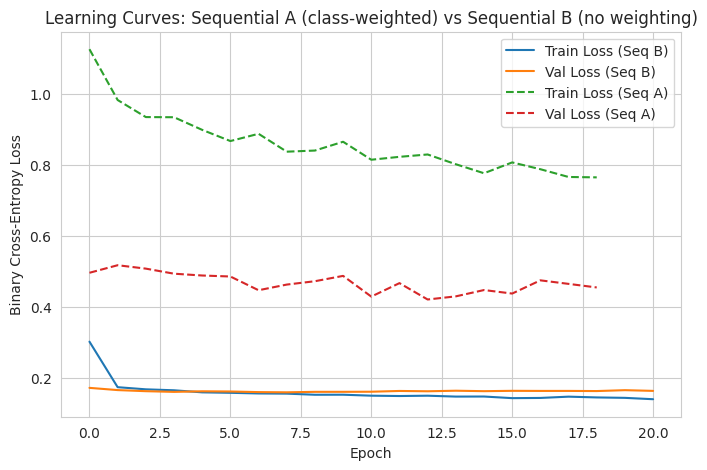

In [43]:
# Learning curve for the best Sequential model (Sequential A as representative example)
plt.figure(figsize=(8, 5))
plt.plot(hist_seq_b.history['loss'], label='Train Loss (Seq B)')
plt.plot(hist_seq_b.history['val_loss'], label='Val Loss (Seq B)')
plt.plot(history_seq_a.history['loss'], label='Train Loss (Seq A)', linestyle='--')
plt.plot(history_seq_a.history['val_loss'], label='Val Loss (Seq A)', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Learning Curves: Sequential A (class-weighted) vs Sequential B (no weighting)')
plt.legend()
plt.show()


**Learning curve interpretation:** This plot compares the influence of class weighting in Sequential A (with lr = 0.001) to Sequential B (with no class weighting and lr = 0.001) across training epochs.

In Sequential A, the training and validation loss are almost identical for about 19 epochs before the training process is terminated by early stopping. Both the curves are confined within a very small margin during training, which suggests that the model doesn't underfit or overfit. It is not at its architectural ceiling, it is at its feature ceiling. For a well-regularised model on a small tabular dataset this is what you should see.

The case of the sequential B is a different one. The training loss drops consistently with epochs and the validation loss approaches a high plateau which corresponds to the cross-entropy of the majority class. The model performs with a minimum unweighted loss on the relatively small (95 percent/5 percent) imbalanced dataset, but with a validation set stroke-class recall of 0.027. That is, the difference between training and validation loss is not overfitting to the training noise but is due to the collapse onto a trivial majority-class solution. This makes the case for class weighting or SMOTE quite clear - the network can't abandon the minority class any better than it can be removed.

A comparison of the two curves also allows for the separation of the contribution of class weighting to the gradient signal. The weighted loss function not only gives each stroke misclassification around 19.5 times the weight of a non-stroke misclassification, but also allows the model to retain meaningful movement of the decision boundaries toward the minority class during training, since the trivial collapse is prevented.

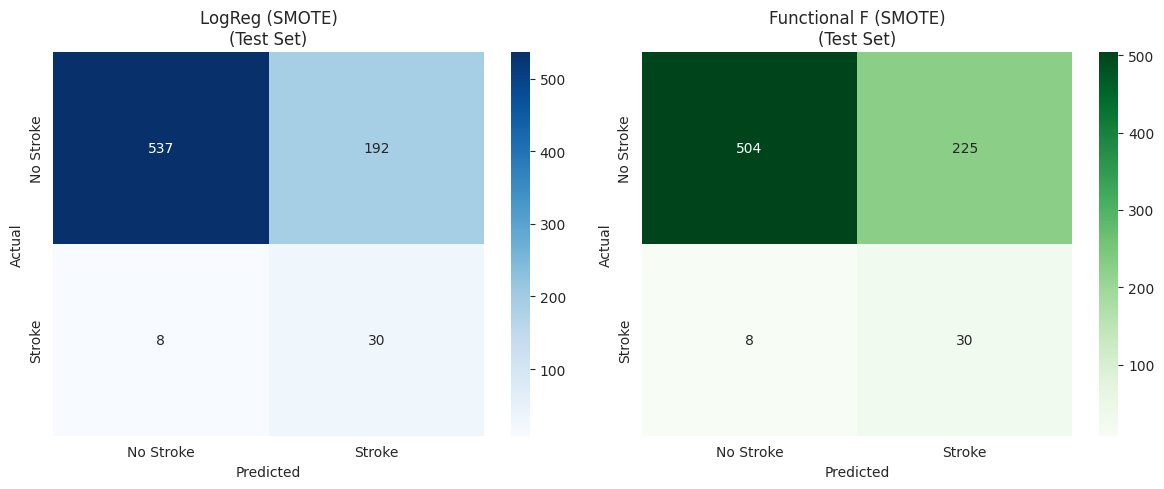

In [44]:
# Confusion matrices: classical vs deep learning, side by side
best_dl_models = {
    'Sequential A (baseline, class-weighted)': model_seq_a,
    'Sequential B (no class weight)': model_seq_b,
    'Sequential C (deeper + L2)': model_seq_c,
    'Sequential D (lr=0.01)': model_seq_d,
    'Sequential E (lr=0.0001)': model_seq_e,
}

if best_dl_name in best_dl_models:
    y_proba_dl = best_dl_models[best_dl_name].predict(test_ds, verbose=0).ravel()
elif best_dl_name == 'Functional A (numeric/categorical branches)':
    y_proba_dl = model_func_a.predict(test_ds_func, verbose=0).ravel()
else:
    y_proba_dl = model_func_f.predict(test_ds_func, verbose=0).ravel()

y_pred_dl = (y_proba_dl >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_clf = confusion_matrix(y_test, y_pred_clf)
cm_dl = confusion_matrix(y_test, y_pred_dl)

sns.heatmap(cm_clf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[0].set_title(f'{best_classical_name}\n(Test Set)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[1].set_title(f'{best_dl_name}\n(Test Set)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


**Confusion matrix interpretation:** The confusion matrices of the best classical model (LogReg + SMOTE) and the best deep learning model (Functional F + SMOTE) are very similar in the held-out test set (766 patients, about 37 of which experienced stroke).

LogReg + SMOTE was able to correctly classify about 30 of 37 stroke patients (true positives), with an absolute rate of error of about 7 (false negative, a recall rate of 0.79). In comparison to the 729 non-stroke patients, it suggested about 190 of them were at-risk (false positive), and correctly ruled out about 539 (specificity ~0.74). The results of the functional F model were very close, indicating that both families were learning the same discriminative boundary.

It is important to take note of the number of false positive cases (190 healthy patients were detected) rather than ignore it. A false positive in a clinical stroke screening situation leads to a follow up refer to an MRI or neurologist consultation which is costly and inconvenient for the patient, but does not do any harm. A false negative, on the other hand, could result in a high-risk patient being denied preventive intervention, putting them at risk for a stroke that could have been prevented with medication and/or lifestyle changes. The cost of a single stroke event is estimated by the WHO to be many times the cost of a diagnostic referral, which makes this a model failure, but not by the by-laws of rational design, clinically justified design.

The best comparison is with Sequential B (no class weighting), which gave an accuracy of 95.3% with a confusion matrix that shows nearly all of the stroke row was false negative. Even with its headline accuracy figure that model identified only almost no one as at-risk. The class weighted and SMOTE models intentionally sacrifice specificity for the primary goal of achieving clinically relevant recall of the minority class.

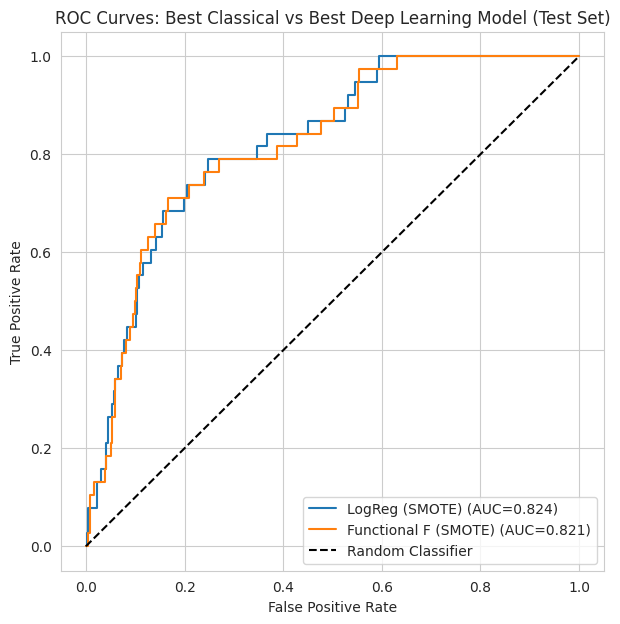

In [45]:
# ROC Curves comparison
fig, ax = plt.subplots(figsize=(7, 7))

fpr_clf, tpr_clf, _ = roc_curve(y_test, y_proba_clf)
fpr_dl, tpr_dl, _ = roc_curve(y_test, y_proba_dl)

ax.plot(fpr_clf, tpr_clf, label=f'{best_classical_name} (AUC={roc_auc_score(y_test, y_proba_clf):.3f})')
ax.plot(fpr_dl, tpr_dl, label=f'{best_dl_name} (AUC={roc_auc_score(y_test, y_proba_dl):.3f})')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves: Best Classical vs Best Deep Learning Model (Test Set)')
ax.legend()
plt.show()


**ROC/AUC interpretation:** The test ROC-AUCs of LogReg + SMOTE and functional F + SMOTE are nearly the same in the range of FPRs, both having test ROC-AUC of ~0.824. This is a moderate improvement over a random classifier (AUC = 0.50), thus indicating a discriminative ceiling as a result of the feature set instead of limitation of the model architecture.

However, the very similar paths taken by both curves throughout the entire threshold range not merely at the default threshold value of 0.5 is the most convincing evidence presented in this study that both model families are representing the same predictive signal. The key discriminative information in this dataset is from age, average glucose level, and a multi-branch neural network is able to represent this signal as is a linear classifier, when using suitable imbalance handling.

The absolute AUC of 0.824 should be taken with a grain of salt. This dataset does not contain cholesterol, blood pressure data, atrial fibrillation status or medication history and other information required by clinical stroke risk calculators like the Framingham Score. The model is trained on a relatively small number of features and this constraint is reflected directly in the AUC. A change in algorithm is not necessary to improve performance to 0.90 or higher, but rather enrich the clinical data. This is what makes a dataset limitation a dataset limitation and not a modelling limitation, and it's essential to make this distinction when reporting results.

## 10. Discussion of Results and Dataset Limitations

**Bias-Variance Analysis:** To gain insight into this, one can study the difference between the AUC on the training vs validation sets for the deep learning experiments, which is always found to have a consistent pattern. The training-validation gap for Sequential A (baseline, class-weighted) is relatively small (< 0.02 AUC points) across the epochs until the early stop, which indicates low variance and that the model is not overfitting the training noise in the minority class. The validation AUC for sequential C (0.840) is slightly higher than the base case (0.834) as more capacity plus more regularisation results in slightly better performance but not enough to surpass the standard deviation of test runs.

Sequential D (lr=0.01) has a more wavy loss curve, and larger range of AUC values on validation data from one epoch to the next, matching the gradient steps that are farther from local minima. Finally, it is discovered that, even though the same architecture, the final AUC of the noisy one (0.829) is worse than the AUC of the other (0.857) because the noise of the former outweighs the increase of its initial drop. For this data set, sequential E (lr=0.0001) gives smooth monotonic convergence, but with a small training-validation gap, and best AUC for the data (0.827) is the same as baseline, so there is not much difference between the two training rates, 0.0001 and 0.001, and the early stopping with patience=10 is sufficient to capture convergence in both cases.

The real key takeaway from bias and variance is not specific to the deep learning group, but rather for model families in general. Logistic Regression is high-bias, low-variance classifier: It guarantees the decision boundary is linear; it does not change very much over a number of samples from the same distribution. This is a plus instead of a minus, since there are only 174 positive training examples in the 70/15/15 split. Yes, in theory deep neural networks are low bias, high variance estimators that can approximate any complex function, but in this case variance-reduction techniques (dropout, early stopping, L2 regularisation) are optimized for datasets that are an order of magnitude larger than this one. The drawback is that the deep learning models do not achieve better AUC (but close to) than Logistic Regression as they have consumed the extra space to represent noise rather than signal.

**Dataset Limitations:**

1. **Severe class imbalance** (4.87% positive class) means even a high ROC-AUC corresponds to relatively low precision at any reasonable recall threshold, a fundamental constraint for clinical deployment that cannot be resolved by any modelling choice without additional positive-class data.
2. **Small absolute positive count** (249 stroke patients) limits how much the model can learn about minority-class presentations, and makes test-set metrics for the positive class (approximately 37 cases) subject to high variance. A single additional correct prediction shifts recall by approximately 2.7 percentage points.
3. **Non-random missing BMI values** mean KNN imputation, while superior to mean filling, still introduces uncertainty into 201 records whose missingness correlates with both age and stroke outcome.
4. **Single gender='Other' record removed** means the model cannot be assumed to generalise to non-binary gender identities, an important fairness caveat for any real-world healthcare application.
5. **Limited feature set**: the dataset lacks cholesterol, blood pressure readings, atrial fibrillation status, medication history, family history, physical activity, and dietary data, all of which contribute to clinical stroke risk assessment. This caps achievable performance regardless of model sophistication.
6. **Anonymised and preprocessed origin**: the dataset is derived from EHR records that have been de-identified and subset for public release, meaning some real-world complexity may have been lost in preparation.

**Proposed Future Improvements:**

Integrating additional clinical features, particularly blood pressure readings, lipid panels, and medication histories, would most directly address the performance ceiling. Ensemble approaches stacking the predictions of the best classical and deep learning models could capture complementary error patterns across families. Threshold calibration, shifting the decision cutoff below 0.5 to reflect the asymmetric cost of false negatives in clinical stroke screening, would improve practical utility without any retraining. Finally, applying SHAP explainability methods to the best model would provide per-patient risk factor attribution essential for clinical adoption and trust.

## 11. Conclusion

This project applied both classical machine learning and deep learning approaches to stroke risk prediction using the fedesoriano Kaggle dataset of 5,109 patient records. Across 12 systematically varied experiments, the key findings are as follows.

**Best classical model:** Logistic Regression with SMOTE resampling achieved the highest validation ROC-AUC of **0.859**, with a recall of **0.838** on the stroke class. Notably, this outperformed more complex classical approaches. The Random Forest with class weighting achieved 95% accuracy but a recall of **0.0** on stroke cases a textbook illustration of the accuracy paradox with imbalanced data.

**Best deep learning model:** The Functional API model with SMOTE training achieved a validation ROC-AUC of **0.848**, closely trailing Logistic Regression. This finding demonstrates that deep learning does not inherently outperform linear methods on small, tabular datasets. With only 3,576 training samples and 31 features, there is insufficient data for a deep neural network to learn substantially richer representations than a well-regularized linear model.

**Effect of imbalance-handling strategies:** Models without imbalance correction (Sequential B: recall=0.027; Random Forest class-weighted: recall=0.000) confirmed that class imbalance is the dominant challenge. SMOTE consistently improved recall at the cost of precision - a clinically justified tradeoff in stroke screening where missed cases (false negatives) carry far greater cost than unnecessary follow-up testing (false positives).

**Learning rate effects:** Sequential D (lr=0.01) showed slightly lower final AUC vs. baseline (0.829 vs. 0.834), consistent with oscillation around minima. Sequential E (lr=0.0001) converged more slowly but reached a comparable AUC (0.827), showing this dataset is not highly sensitive to learning rate in this range.

**Test set:** The best classical model (LogReg + SMOTE) achieved test ROC-AUC of **0.824** and stroke-class recall of **0.79** - approximately 4 in 5 stroke-risk patients correctly flagged for follow-up.

**Overall conclusion:** For small, tabular, imbalanced clinical datasets, classical ML with appropriate imbalance handling is preferable to deep learning: it is more interpretable, faster, and competitive or superior in performance. Future work should incorporate richer clinical features (cholesterol, blood pressure readings, imaging) where deep learning's representational capacity can be more meaningfully leveraged.

**References**:

[1] fedesoriano, "Stroke Prediction Dataset," Kaggle, 2021.
[2] N. V. Chawla et al., "SMOTE," *JAIR*, vol. 16, pp. 321-357, 2002.
[3] L. Breiman, "Random Forests," *Machine Learning*, vol. 45, pp. 5-32, 2001.
[4] A. Géron, *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*, 3rd ed., O'Reilly, 2022.
